In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df = pd.read_csv("data/cs-training.csv",index_col=0)
df.shape

(150000, 11)

In [3]:
df.sample(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
98762,0,0.057602,61,0,0.302951,8370.0,4,0,1,0,1.0
129070,0,0.614980,55,0,0.288184,12897.0,10,0,2,0,1.0
7387,0,0.035893,77,0,253.000000,NaN,7,0,0,0,0.0
144389,1,1.180995,51,2,571.000000,NaN,5,3,0,1,NaN
71816,0,1.000000,61,0,0.156378,5134.0,4,0,0,0,0.0
45304,0,0.832550,43,0,0.143223,4300.0,5,0,0,0,1.0
136837,0,0.478410,52,0,0.413765,6203.0,19,0,1,0,0.0
129607,0,0.652080,52,1,0.436005,5937.0,9,0,1,0,0.0
125526,0,0.013608,85,0,0.147521,1653.0,4,0,0,0,0.0
148901,0,0.085952,60,0,0.554081,5500.0,9,0,1,1,0.0


In [4]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [5]:
df = df.rename(columns={
    "SeriousDlqin2yrs": "default",
    "RevolvingUtilizationOfUnsecuredLines": "rev_util(percent)",
    "age": "age(years)",
    "NumberOfTime30-59DaysPastDueNotWorse": "late_30_59",
    "DebtRatio": "debt_ratio(percent)",
    "MonthlyIncome": "income",
    "NumberOfOpenCreditLinesAndLoans": "open_credit",
    "NumberOfTimes90DaysLate": "late_90_",
    "NumberRealEstateLoansOrLines": "real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse": "late_60_89",
    "NumberOfDependents": "dependents"
})
df.sample(10)

,default,rev_util(percent),age(years),late_30_59,debt_ratio(percent),income,open_credit,late_90_,real_estate_loans,late_60_89,dependents
52811,0,0.093997,46,0,0.819752,3300.0,19,0,1,0,2.0
85857,0,0.285829,69,0,0.684024,4512.0,7,0,2,0,0.0
75281,0,0.004872,63,0,0.107987,14510.0,9,0,2,0,0.0
99030,0,0.068427,58,0,0.530378,7916.0,12,0,1,0,2.0
69965,0,0.415246,48,0,0.352529,5000.0,10,0,0,0,1.0
49347,0,0.335439,68,0,0.355058,7057.0,8,0,2,0,1.0
6832,1,1.004581,49,0,0.309010,4028.0,6,2,1,0,0.0
26123,0,0.110413,56,1,0.299018,7226.0,12,0,1,0,0.0
137820,0,0.815060,53,0,2716.000000,NaN,11,0,1,0,0.0
114570,0,0.001526,61,0,0.222971,3116.0,5,0,0,0,0.0


In [6]:
df.count()

default                150000
rev_util(percent)      150000
age(years)             150000
late_30_59             150000
debt_ratio(percent)    150000
income                 120269
open_credit            150000
late_90_               150000
real_estate_loans      150000
late_60_89             150000
dependents             146076
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   default              150000 non-null  int64  
 1   rev_util(percent)    150000 non-null  float64
 2   age(years)           150000 non-null  int64  
 3   late_30_59           150000 non-null  int64  
 4   debt_ratio(percent)  150000 non-null  float64
 5   income               120269 non-null  float64
 6   open_credit          150000 non-null  int64  
 7   late_90_             150000 non-null  int64  
 8   real_estate_loans    150000 non-null  int64  
 9   late_60_89           150000 non-null  int64  
 10  dependents           146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 13.7 MB


In [8]:
df.dropna(inplace=True)
df

,default,rev_util(percent),age(years),late_30_59,debt_ratio(percent),income,open_credit,late_90_,real_estate_loans,late_60_89,dependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.385742,50,0,0.404293,3400.0,7,0,0,0,0.0
149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120269 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   default              120269 non-null  int64  
 1   rev_util(percent)    120269 non-null  float64
 2   age(years)           120269 non-null  int64  
 3   late_30_59           120269 non-null  int64  
 4   debt_ratio(percent)  120269 non-null  float64
 5   income               120269 non-null  float64
 6   open_credit          120269 non-null  int64  
 7   late_90_             120269 non-null  int64  
 8   real_estate_loans    120269 non-null  int64  
 9   late_60_89           120269 non-null  int64  
 10  dependents           120269 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 11.0 MB


In [10]:
df.describe()

,default,rev_util(percent),age(years),late_30_59,debt_ratio(percent),income,open_credit,late_90_,real_estate_loans,late_60_89,dependents
count,120269.000000,120269.000000,120269.000000,120269.000000,120269.000000,1.202690e+05,120269.000000,120269.000000,120269.000000,120269.000000,120269.000000
mean,0.069486,5.899873,51.289792,0.381769,26.598777,6.670221e+03,8.758475,0.211925,1.054519,0.187829,0.851832
std,0.254280,257.040685,14.426684,3.499234,424.446457,1.438467e+04,5.172835,3.465276,1.149273,3.447901,1.148391
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.035084,40.000000,0.000000,0.143388,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.177282,51.000000,0.000000,0.296023,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.579428,61.000000,0.000000,0.482559,8.249000e+03,11.000000,0.000000,2.000000,0.000000,2.000000
max,1.000000,50708.000000,103.000000,98.000000,61106.500000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [11]:
df.nunique()

default                     2
rev_util(percent)      103063
age(years)                 83
late_30_59                 16
debt_ratio(percent)    109658
income                  13594
open_credit                58
late_90_                   19
real_estate_loans          28
late_60_89                 13
dependents                 13
dtype: int64

In [12]:
target = ["default"]
features = df.columns[1:]
len(features)

10

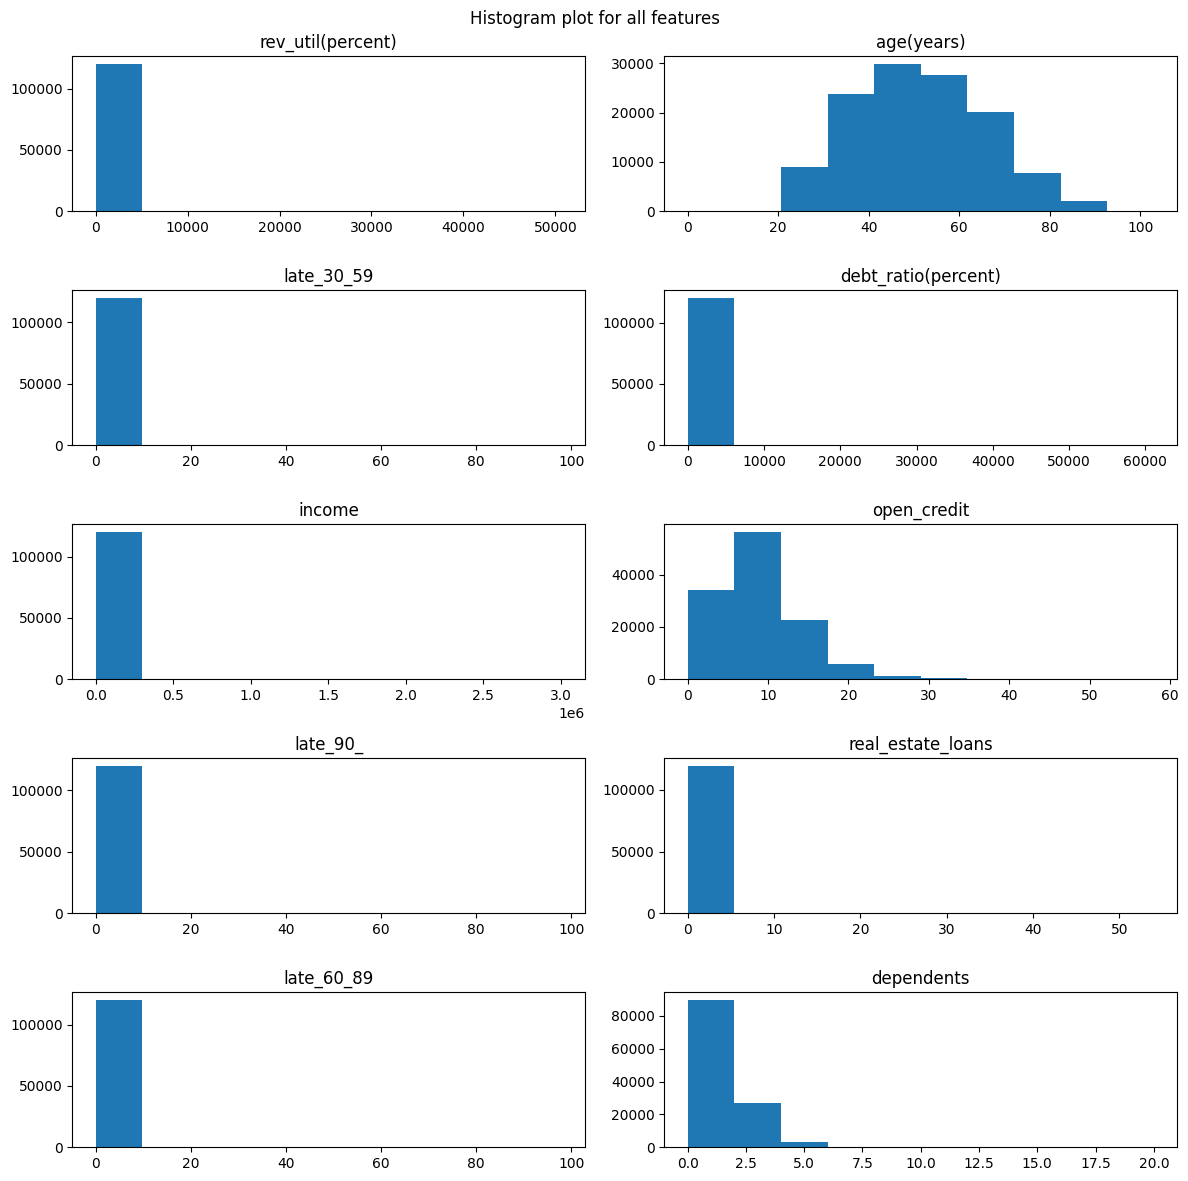

In [13]:
fig, ax = plt.subplots(5,2,figsize = (12,12))

for i in range(len(features)):
    row = i//2
    col = i%2
    ax[row,col].hist(df[features[i]])
    ax[row,col].set_xlabel(None)
    ax[row,col].set_title(f"{features[i]}")
fig.suptitle("Histogram plot for all features")
plt.tight_layout()

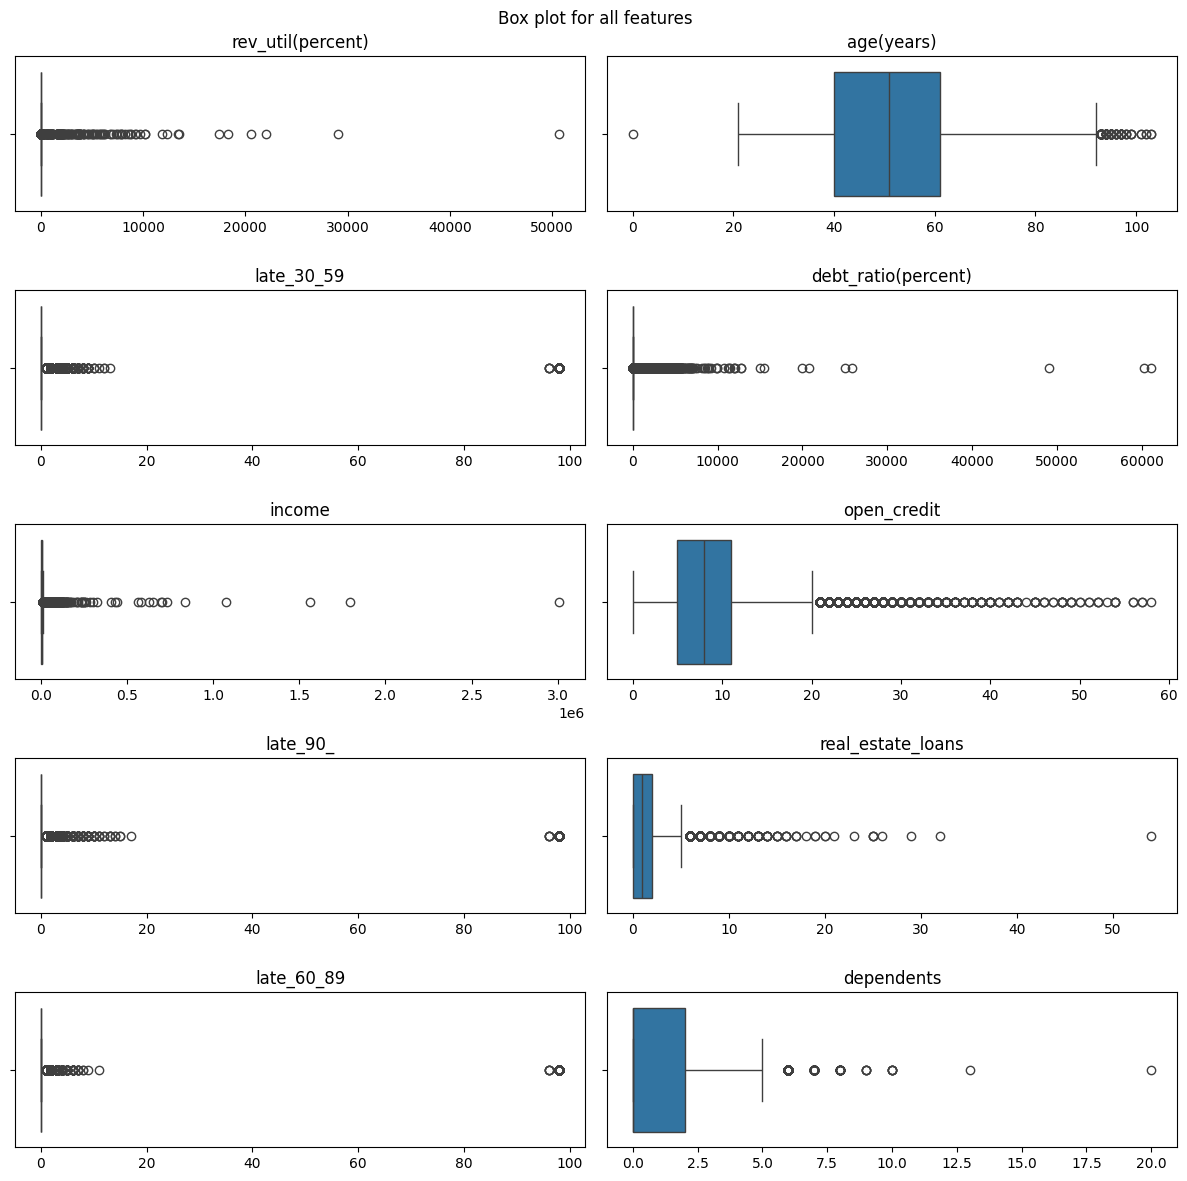

In [14]:
fig, ax = plt.subplots(5,2,figsize = (12,12))

for i in range(len(features)):
    row = i//2
    col = i%2
    sns.boxplot(df,x=features[i],ax=ax[row,col])
    ax[row,col].set_xlabel(None)
    ax[row,col].set_title(f"{features[i]}")
fig.suptitle("Box plot for all features")
plt.tight_layout()

In [15]:
df = df[(df["rev_util(percent)"] <= 1.5) & (df["debt_ratio(percent)"] <= 5)].reset_index(drop=True)
df = df[(df["late_30_59"] <= 10) & (df["late_90_"] <= 10) & (df["late_60_89"] <= 10)].reset_index(drop=True)
df = df[(df["age(years)"] > 15)].reset_index(drop=True)
df.shape

(117306, 11)

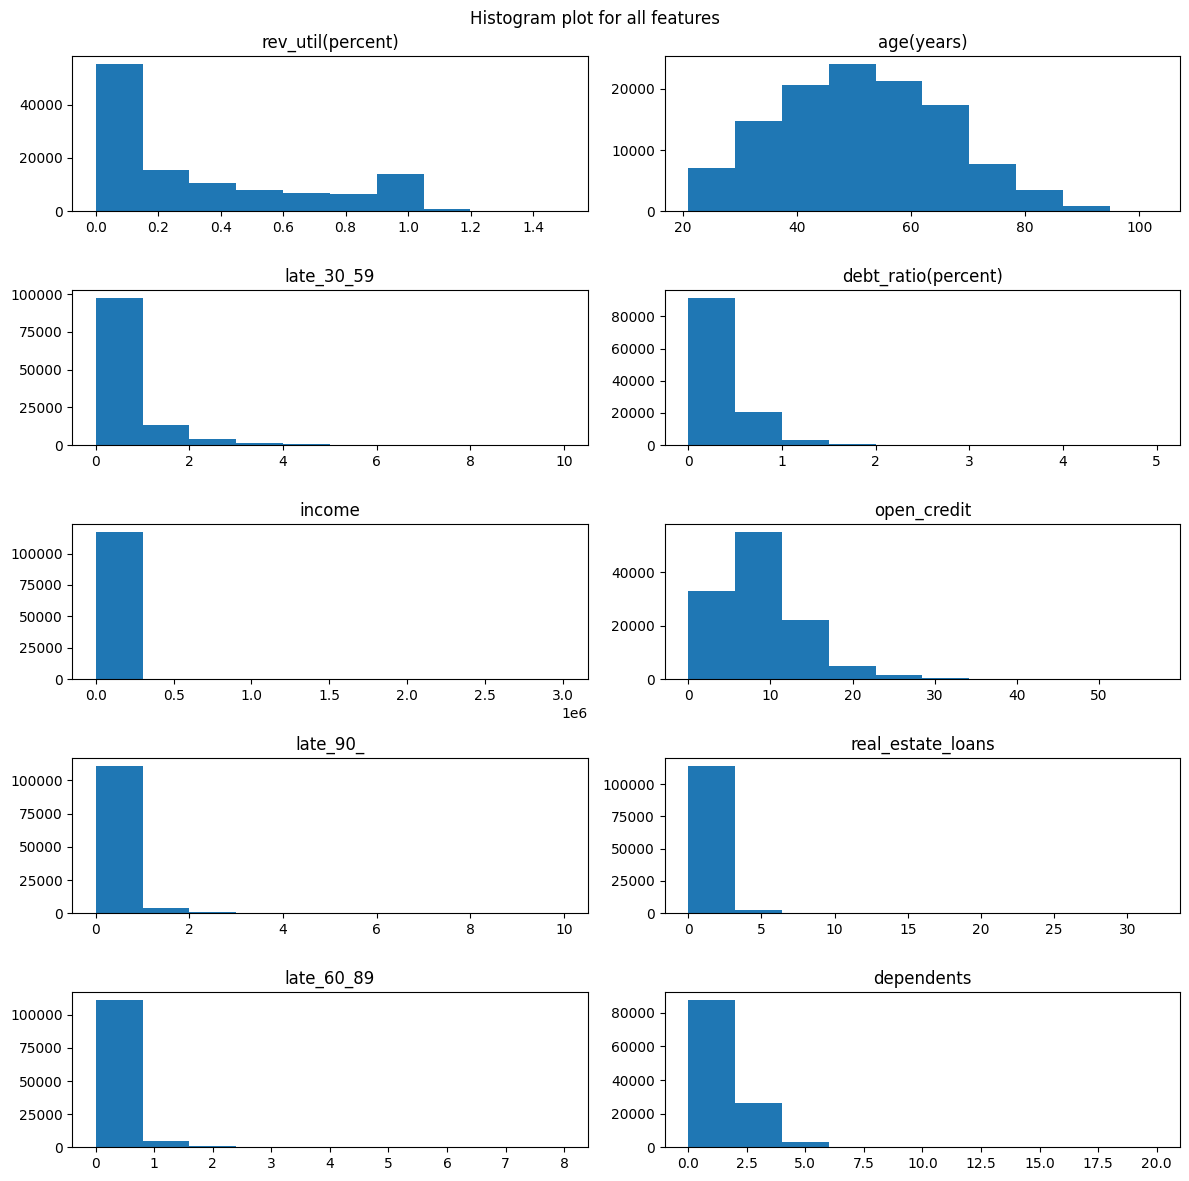

In [16]:
fig, ax = plt.subplots(5,2,figsize = (12,12))

for i in range(len(features)):
    row = i//2
    col = i%2
    ax[row,col].hist(df[features[i]])
    ax[row,col].set_xlabel(None)
    ax[row,col].set_title(f"{features[i]}")
fig.suptitle("Histogram plot for all features")
plt.tight_layout()

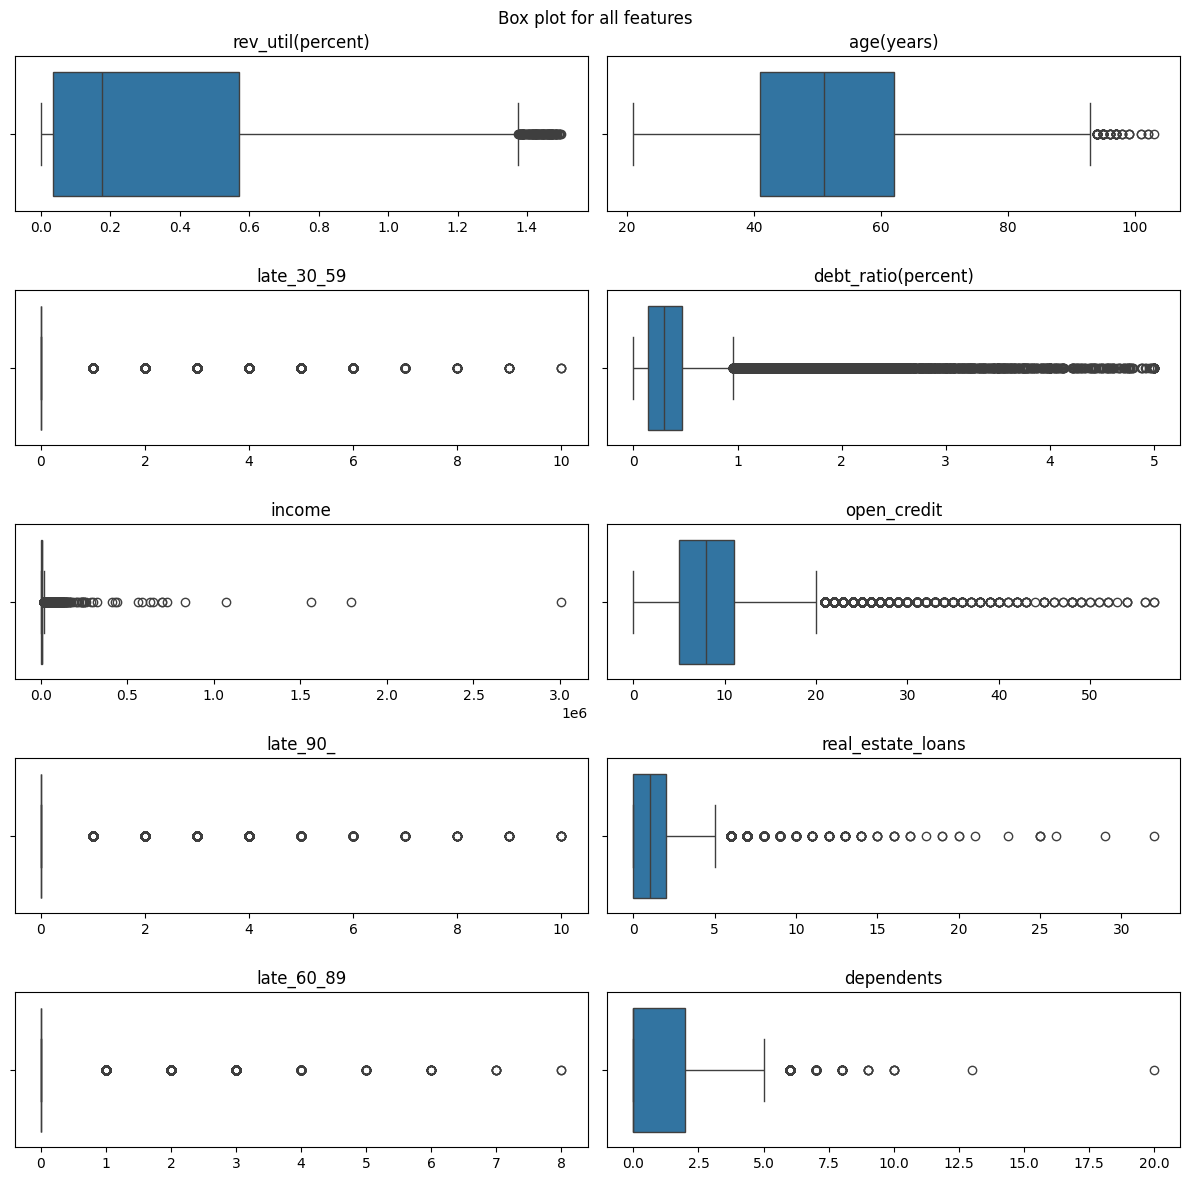

In [17]:
fig, ax = plt.subplots(5,2,figsize = (12,12))

for i in range(len(features)):
    row = i//2
    col = i%2
    sns.boxplot(df,x=features[i],ax=ax[row,col])
    ax[row,col].set_xlabel(None)
    ax[row,col].set_title(f"{features[i]}")
fig.suptitle("Box plot for all features")
plt.tight_layout()

In [18]:
df.describe()

,default,rev_util(percent),age(years),late_30_59,debt_ratio(percent),income,open_credit,late_90_,real_estate_loans,late_60_89,dependents
count,117306.000000,117306.000000,117306.000000,117306.000000,117306.000000,1.173060e+05,117306.000000,117306.000000,117306.000000,117306.000000,117306.000000
mean,0.068556,0.328891,51.372556,0.260779,0.361022,6.802657e+03,8.794947,0.088222,1.058556,0.066365,0.851423
std,0.252698,0.348846,14.402223,0.715276,0.374466,1.452857e+04,5.168818,0.460132,1.140311,0.330617,1.146673
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.034857,41.000000,0.000000,0.140747,3.500000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.175839,51.000000,0.000000,0.290668,5.495000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.571011,62.000000,0.000000,0.468421,8.333000e+03,11.000000,0.000000,2.000000,0.000000,2.000000
max,1.000000,1.499474,103.000000,10.000000,5.000000,3.008750e+06,57.000000,10.000000,32.000000,8.000000,20.000000


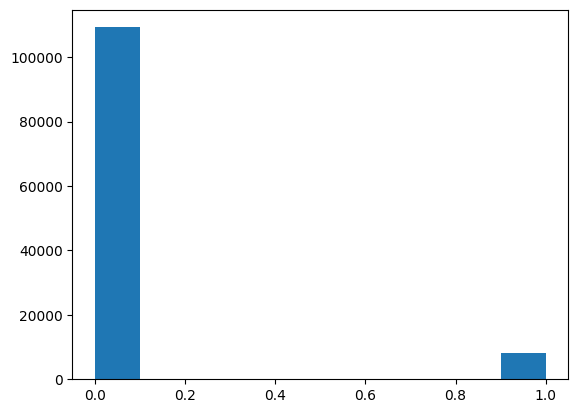

In [20]:
plt.hist(df[target])
plt.show()

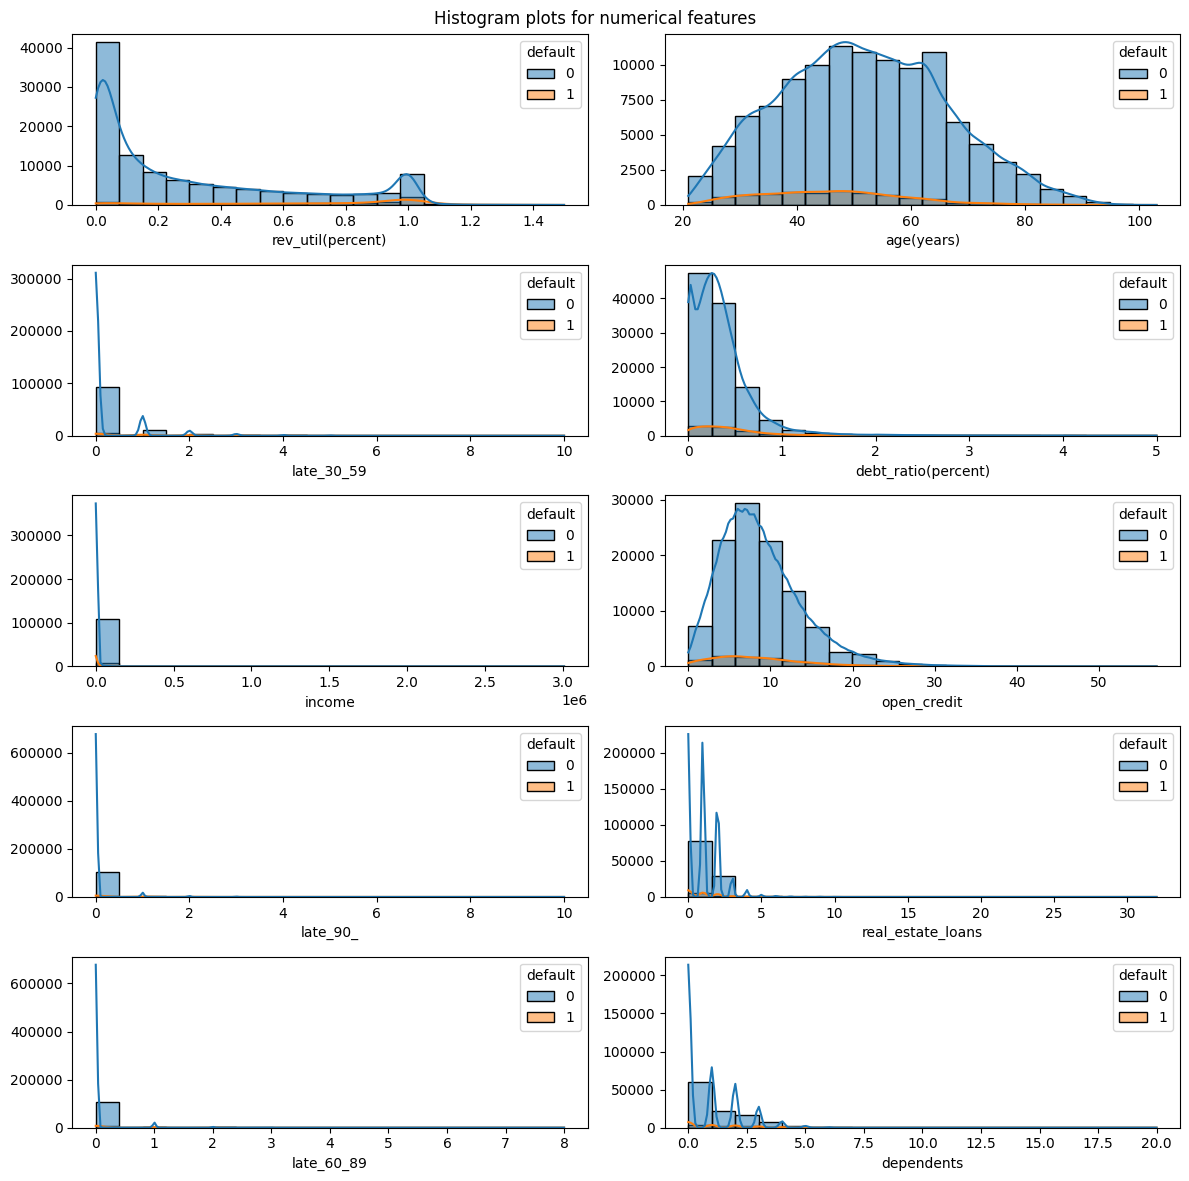

In [21]:
fig, ax = plt.subplots(nrows=5, ncols=2, figsize = (12,12))
for k,var in enumerate(features):
    row = int(k//2)
    col = int(k%2)
    sns.histplot(data = df, x = var, bins= 20, hue = "default", ax=ax[row,col],kde=True)
    ax[row,col].set_ylabel(None)
plt.suptitle("Histogram plots for numerical features")      #Histogram plot for numerical features
plt.tight_layout()

In [22]:
scaler = StandardScaler()
scaled_data = scaler.fit(df[features])
scaled_numerical_data = scaler.transform(df[features])
df[features] = scaled_numerical_data
df.sample(10)

,default,rev_util(percent),age(years),late_30_59,debt_ratio(percent),income,open_credit,late_90_,real_estate_loans,late_60_89,dependents
106853,1,1.589921,-1.206246,-0.364588,0.297067,0.140919,1.200483,-0.191733,0.825606,-0.200731,1.873757
19653,0,0.407030,-0.859076,-0.364588,-0.374705,1.940829,-0.153797,-0.191733,0.825606,-0.200731,1.001665
40596,0,-0.799616,0.737906,-0.364588,-0.486361,0.219248,-0.927672,-0.191733,-0.051351,-0.200731,0.129573
4757,0,-0.858233,-0.581340,-0.364588,2.128168,-0.256507,0.233140,-0.191733,1.702564,-0.200731,-0.742519
55371,0,-0.584296,-0.164736,-0.364588,0.001796,0.288904,0.426609,-0.191733,0.825606,-0.200731,0.129573
88429,0,-0.216710,0.807340,-0.364588,1.279726,-0.127519,1.200483,-0.191733,-0.051351,-0.200731,-0.742519
31587,0,-0.792705,-0.164736,-0.364588,-0.493680,0.162738,-0.540735,-0.191733,-0.051351,-0.200731,0.129573
35373,0,-0.848192,-0.442472,-0.364588,-0.650712,-0.179141,-0.347266,-0.191733,-0.928309,-0.200731,0.129573
99349,1,0.789726,0.946208,1.033481,0.009611,-0.220440,0.039671,-0.191733,-0.928309,8.873244,1.001665
52488,0,-0.942799,0.113000,-0.364588,-0.425698,-0.118364,0.039671,-0.191733,-0.928309,-0.200731,-0.742519


In [23]:
corr_matrix = df[features].corr()
corr_matrix

,rev_util(percent),age(years),late_30_59,debt_ratio(percent),income,open_credit,late_90_,real_estate_loans,late_60_89,dependents
rev_util(percent),1.000000,-0.264014,0.244359,0.116350,-0.036840,-0.162414,0.244371,-0.075634,0.197176,0.084223
age(years),-0.264014,1.000000,-0.061421,-0.045425,0.036183,0.183756,-0.077298,0.063732,-0.063646,-0.206723
late_30_59,0.244359,-0.061421,1.000000,0.085454,-0.002685,0.069438,0.226256,0.037790,0.304890,0.058549
debt_ratio(percent),0.116350,-0.045425,0.085454,1.000000,-0.068715,0.260695,0.000426,0.400383,0.033743,0.046277
income,-0.036840,0.036183,-0.002685,-0.068715,1.000000,0.090226,-0.020637,0.125631,-0.011930,0.063454
open_credit,-0.162414,0.183756,0.069438,0.260695,0.090226,1.000000,-0.097816,0.425728,-0.025310,0.038287
late_90_,0.244371,-0.077298,0.226256,0.000426,-0.020637,-0.097816,1.000000,-0.066142,0.298912,0.036509
real_estate_loans,-0.075634,0.063732,0.037790,0.400383,0.125631,0.425728,-0.066142,1.000000,-0.021795,0.119547
late_60_89,0.197176,-0.063646,0.304890,0.033743,-0.011930,-0.025310,0.298912,-0.021795,1.000000,0.037140
dependents,0.084223,-0.206723,0.058549,0.046277,0.063454,0.038287,0.036509,0.119547,0.037140,1.000000


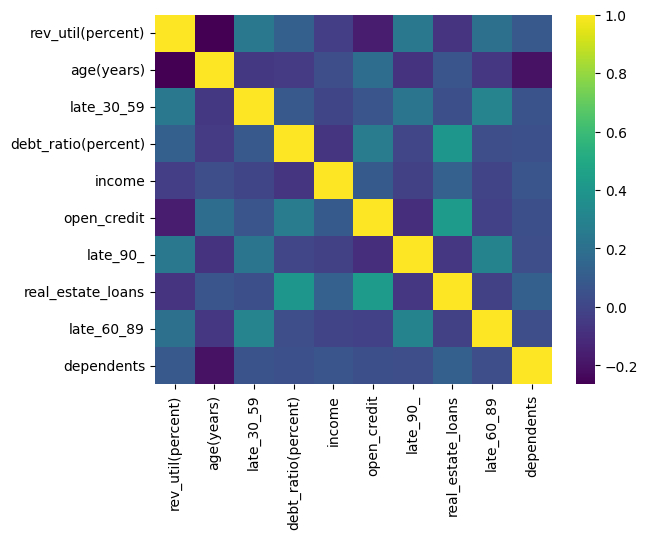

In [24]:
sns.heatmap(data= corr_matrix,cmap="viridis")
plt.show()

In [25]:
df.sample(10)

,default,rev_util(percent),age(years),late_30_59,debt_ratio(percent),income,open_credit,late_90_,real_estate_loans,late_60_89,dependents
56287,0,1.158803,-1.553416,-0.364588,0.003516,-0.367048,-0.734203,-0.191733,-0.928309,-0.200731,-0.742519
53128,0,-0.861270,0.529604,-0.364588,0.020357,-0.144726,-0.927672,-0.191733,-0.051351,-0.200731,1.001665
27380,0,-0.401827,-0.928510,-0.364588,1.245891,-0.146172,0.233140,-0.191733,0.825606,-0.200731,0.129573
105142,0,-0.894070,-0.025868,-0.364588,0.055266,0.101686,-0.540735,-0.191733,1.702564,-0.200731,-0.742519
104995,0,-0.753459,-0.303604,-0.364588,1.479004,-0.268621,2.748233,-0.191733,1.702564,-0.200731,1.001665
72310,0,-0.387921,-0.234170,-0.364588,-0.311747,-0.164274,0.426609,-0.191733,-0.928309,-0.200731,1.873757
47232,0,1.654612,-0.720208,-0.364588,-0.950974,0.007801,-1.121141,-0.191733,-0.928309,-0.200731,1.001665
99966,0,0.622083,0.390736,-0.364588,-0.092699,0.750066,1.007015,-0.191733,1.702564,-0.200731,0.129573
21842,0,-0.080134,0.390736,1.033481,0.066461,0.292759,1.200483,-0.191733,-0.051351,-0.200731,1.873757
87633,0,-0.320709,0.599038,1.033481,-0.075060,0.025009,2.748233,-0.191733,0.825606,-0.200731,0.129573


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features], 
    df[target].astype(int), 
    test_size=0.2, 
)   


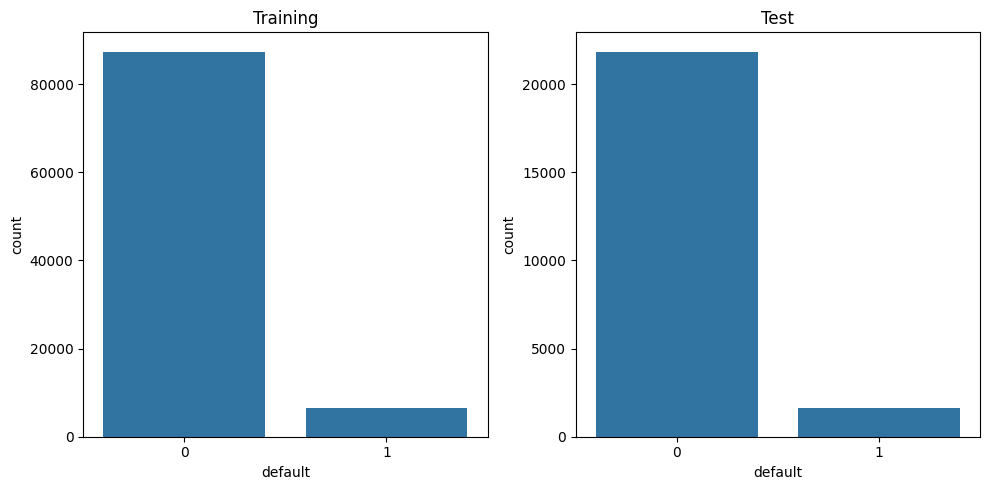

In [27]:
#looking at the counts for training and test dataset
fig, ax = plt.subplots(1,2,figsize = (10,5))

sns.countplot(x = y_train.squeeze(), ax = ax[0])
ax[0].set_title("Training")
sns.countplot(x = y_test.squeeze(), ax = ax[1])
ax[1].set_title("Test")
plt.tight_layout()

In [27]:
X_train_tensor = torch.from_numpy(X_train.values.astype(np.float32))
X_test_tensor  = torch.from_numpy(X_test.values.astype(np.float32))

y_train_tensor = torch.from_numpy(y_train.values.astype(np.float32)).view(-1, 1)  # (N, 1)
y_test_tensor  = torch.from_numpy(y_test.values.astype(np.float32)).view(-1, 1)

In [28]:
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds  = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 256

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [132]:
torch.manual_seed(42)
np.random.seed(42)

In [133]:
input_dim = X_train_tensor.shape[1]

class CreditNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, 1),   # output logits
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.net(x)  # logits, no sigmoid here

model = CreditNet(input_dim)


In [134]:
loss_function = nn.BCELoss()

## SGD

### SGD with vs without momentum

In [63]:
optimizer = torch.optim.SGD(model.parameters())

In [64]:
n_epochs = 200
train_losses_SGD_without_momentum = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        logits = model(X_batch)            # (batch_size, 1)
        loss = loss_function(logits, y_batch)  # y_batch is (batch_size, 1)
    
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses_SGD_without_momentum.append(epoch_loss)
    if epoch %10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - train loss: {epoch_loss:.4f}")


Epoch 1/200 - train loss: 0.7077
Epoch 11/200 - train loss: 0.2860
Epoch 21/200 - train loss: 0.2164
Epoch 31/200 - train loss: 0.1993
Epoch 41/200 - train loss: 0.1934
Epoch 51/200 - train loss: 0.1903
Epoch 61/200 - train loss: 0.1892
Epoch 71/200 - train loss: 0.1883
Epoch 81/200 - train loss: 0.1876
Epoch 91/200 - train loss: 0.1873
Epoch 101/200 - train loss: 0.1866
Epoch 111/200 - train loss: 0.1865
Epoch 121/200 - train loss: 0.1862
Epoch 131/200 - train loss: 0.1857
Epoch 141/200 - train loss: 0.1857
Epoch 151/200 - train loss: 0.1857
Epoch 161/200 - train loss: 0.1856
Epoch 171/200 - train loss: 0.1852
Epoch 181/200 - train loss: 0.1851
Epoch 191/200 - train loss: 0.1852


In [65]:
model.eval()
correct, total = 0, 0
predicted_classes = []
actual_classes = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        actual_classes.extend(y_batch)
        outputs = model(X_batch)
        # print(outputs)
        # probs = torch.sigmoid(outputs)
        preds = (outputs >= 0.5).float()
        predicted_classes.extend(preds)
        correct += (preds == y_batch).sum().item()               # returns the number of correctly classified X_batch
        total += y_batch.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")           # accuracy score of the model


Test Accuracy: 93.34%


#### SGD with momentum

##### $\beta = 0.9$

In [69]:
optimizer = torch.optim.SGD(model.parameters(),momentum=0.9)

In [70]:
n_epochs = 200
train_losses_SGD_9 = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        logits = model(X_batch)            # (batch_size, 1)
        loss = loss_function(logits, y_batch)  # y_batch is (batch_size, 1)
    
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses_SGD_9.append(epoch_loss)
    if epoch %10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - train loss: {epoch_loss:.4f}")


Epoch 1/200 - train loss: 0.4581
Epoch 11/200 - train loss: 0.1869
Epoch 21/200 - train loss: 0.1853
Epoch 31/200 - train loss: 0.1848
Epoch 41/200 - train loss: 0.1842
Epoch 51/200 - train loss: 0.1837
Epoch 61/200 - train loss: 0.1836
Epoch 71/200 - train loss: 0.1832
Epoch 81/200 - train loss: 0.1831
Epoch 91/200 - train loss: 0.1828
Epoch 101/200 - train loss: 0.1825
Epoch 111/200 - train loss: 0.1824
Epoch 121/200 - train loss: 0.1819
Epoch 131/200 - train loss: 0.1819
Epoch 141/200 - train loss: 0.1817
Epoch 151/200 - train loss: 0.1814
Epoch 161/200 - train loss: 0.1813
Epoch 171/200 - train loss: 0.1810
Epoch 181/200 - train loss: 0.1808
Epoch 191/200 - train loss: 0.1809


In [72]:
model.eval()
correct, total = 0, 0
predicted_classes = []
actual_classes = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        actual_classes.extend(y_batch)
        outputs = model(X_batch)
        # print(outputs)
        # probs = torch.sigmoid(outputs)
        preds = (outputs >= 0.5).float()
        predicted_classes.extend(preds)
        correct += (preds == y_batch).sum().item()               # returns the number of correctly classified X_batch
        total += y_batch.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")           # accuracy score of the model


Test Accuracy: 93.36%


##### $\beta=0.7$

In [78]:
optimizer = torch.optim.SGD(model.parameters(),momentum=0.7)

In [79]:
n_epochs = 200
train_losses_SGD_7 = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        logits = model(X_batch)            # (batch_size, 1)
        loss = loss_function(logits, y_batch)  # y_batch is (batch_size, 1)
    
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses_SGD_7.append(epoch_loss)
    if epoch %10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - train loss: {epoch_loss:.4f}")


Epoch 1/200 - train loss: 0.6058
Epoch 11/200 - train loss: 0.1962
Epoch 21/200 - train loss: 0.1884
Epoch 31/200 - train loss: 0.1868
Epoch 41/200 - train loss: 0.1860
Epoch 51/200 - train loss: 0.1852
Epoch 61/200 - train loss: 0.1852
Epoch 71/200 - train loss: 0.1849
Epoch 81/200 - train loss: 0.1848
Epoch 91/200 - train loss: 0.1846
Epoch 101/200 - train loss: 0.1843
Epoch 111/200 - train loss: 0.1842
Epoch 121/200 - train loss: 0.1839
Epoch 131/200 - train loss: 0.1837
Epoch 141/200 - train loss: 0.1837
Epoch 151/200 - train loss: 0.1835
Epoch 161/200 - train loss: 0.1835
Epoch 171/200 - train loss: 0.1831
Epoch 181/200 - train loss: 0.1829
Epoch 191/200 - train loss: 0.1831


In [80]:
model.eval()
correct, total = 0, 0
predicted_classes = []
actual_classes = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        actual_classes.extend(y_batch)
        outputs = model(X_batch)
        # print(outputs)
        # probs = torch.sigmoid(outputs)
        preds = (outputs >= 0.5).float()
        predicted_classes.extend(preds)
        correct += (preds == y_batch).sum().item()               # returns the number of correctly classified X_batch
        total += y_batch.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")           # accuracy score of the model


Test Accuracy: 93.34%


##### $\beta=0.5$

In [84]:
optimizer = torch.optim.SGD(model.parameters(),momentum=0.5)

In [85]:
n_epochs = 200
train_losses_SGD_5 = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        logits = model(X_batch)            # (batch_size, 1)
        loss = loss_function(logits, y_batch)  # y_batch is (batch_size, 1)
    
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses_SGD_5.append(epoch_loss)
    if epoch %10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - train loss: {epoch_loss:.4f}")


Epoch 1/200 - train loss: 0.6571
Epoch 11/200 - train loss: 0.2150
Epoch 21/200 - train loss: 0.1932
Epoch 31/200 - train loss: 0.1891
Epoch 41/200 - train loss: 0.1875
Epoch 51/200 - train loss: 0.1864
Epoch 61/200 - train loss: 0.1863
Epoch 71/200 - train loss: 0.1859
Epoch 81/200 - train loss: 0.1856
Epoch 91/200 - train loss: 0.1854
Epoch 101/200 - train loss: 0.1851
Epoch 111/200 - train loss: 0.1850
Epoch 121/200 - train loss: 0.1848
Epoch 131/200 - train loss: 0.1845
Epoch 141/200 - train loss: 0.1845
Epoch 151/200 - train loss: 0.1844
Epoch 161/200 - train loss: 0.1844
Epoch 171/200 - train loss: 0.1840
Epoch 181/200 - train loss: 0.1839
Epoch 191/200 - train loss: 0.1840


In [86]:
model.eval()
correct, total = 0, 0
predicted_classes = []
actual_classes = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        actual_classes.extend(y_batch)
        outputs = model(X_batch)
        # print(outputs)
        # probs = torch.sigmoid(outputs)
        preds = (outputs >= 0.5).float()
        predicted_classes.extend(preds)
        correct += (preds == y_batch).sum().item()               # returns the number of correctly classified X_batch
        total += y_batch.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")           # accuracy score of the model


Test Accuracy: 93.33%


##### $\beta=0.3$

In [90]:
optimizer = torch.optim.SGD(model.parameters(),momentum=0.3)

In [91]:
n_epochs = 200
train_losses_SGD_3 = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        logits = model(X_batch)            # (batch_size, 1)
        loss = loss_function(logits, y_batch)  # y_batch is (batch_size, 1)
    
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses_SGD_3.append(epoch_loss)
    if epoch %10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - train loss: {epoch_loss:.4f}")


Epoch 1/200 - train loss: 0.6842
Epoch 11/200 - train loss: 0.2416
Epoch 21/200 - train loss: 0.2005
Epoch 31/200 - train loss: 0.1924
Epoch 41/200 - train loss: 0.1894
Epoch 51/200 - train loss: 0.1877
Epoch 61/200 - train loss: 0.1873
Epoch 71/200 - train loss: 0.1868
Epoch 81/200 - train loss: 0.1864
Epoch 91/200 - train loss: 0.1862
Epoch 101/200 - train loss: 0.1857
Epoch 111/200 - train loss: 0.1856
Epoch 121/200 - train loss: 0.1854
Epoch 131/200 - train loss: 0.1850
Epoch 141/200 - train loss: 0.1850
Epoch 151/200 - train loss: 0.1850
Epoch 161/200 - train loss: 0.1850
Epoch 171/200 - train loss: 0.1846
Epoch 181/200 - train loss: 0.1844
Epoch 191/200 - train loss: 0.1846


In [92]:
model.eval()
correct, total = 0, 0
predicted_classes = []
actual_classes = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        actual_classes.extend(y_batch)
        outputs = model(X_batch)
        # print(outputs)
        # probs = torch.sigmoid(outputs)
        preds = (outputs >= 0.5).float()
        predicted_classes.extend(preds)
        correct += (preds == y_batch).sum().item()               # returns the number of correctly classified X_batch
        total += y_batch.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")           # accuracy score of the model


Test Accuracy: 93.34%


##### $\beta = 0.1$

In [96]:
optimizer = torch.optim.SGD(model.parameters(),momentum=0.1)

In [97]:
n_epochs = 200
train_losses_SGD_1 = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        logits = model(X_batch)            # (batch_size, 1)
        loss = loss_function(logits, y_batch)  # y_batch is (batch_size, 1)
    
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses_SGD_1.append(epoch_loss)
    if epoch %10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - train loss: {epoch_loss:.4f}")


Epoch 1/200 - train loss: 0.7013
Epoch 11/200 - train loss: 0.2711
Epoch 21/200 - train loss: 0.2105
Epoch 31/200 - train loss: 0.1967
Epoch 41/200 - train loss: 0.1919
Epoch 51/200 - train loss: 0.1894
Epoch 61/200 - train loss: 0.1885
Epoch 71/200 - train loss: 0.1877
Epoch 81/200 - train loss: 0.1872
Epoch 91/200 - train loss: 0.1869
Epoch 101/200 - train loss: 0.1863
Epoch 111/200 - train loss: 0.1862
Epoch 121/200 - train loss: 0.1859
Epoch 131/200 - train loss: 0.1855
Epoch 141/200 - train loss: 0.1855
Epoch 151/200 - train loss: 0.1855
Epoch 161/200 - train loss: 0.1854
Epoch 171/200 - train loss: 0.1850
Epoch 181/200 - train loss: 0.1849
Epoch 191/200 - train loss: 0.1850


In [98]:
model.eval()
correct, total = 0, 0
predicted_classes = []
actual_classes = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        actual_classes.extend(y_batch)
        outputs = model(X_batch)
        # print(outputs)
        # probs = torch.sigmoid(outputs)
        preds = (outputs >= 0.5).float()
        predicted_classes.extend(preds)
        correct += (preds == y_batch).sum().item()               # returns the number of correctly classified X_batch
        total += y_batch.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")           # accuracy score of the model


Test Accuracy: 93.33%


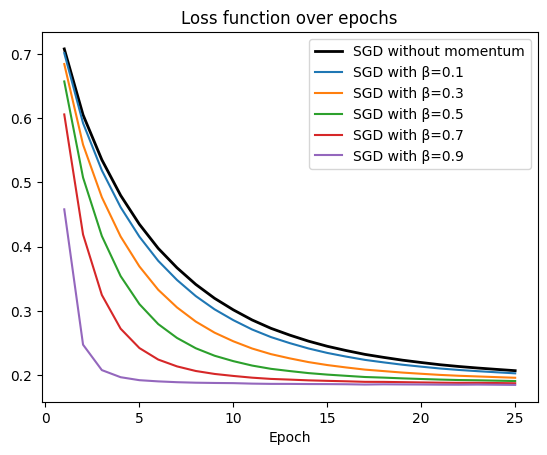

In [111]:
epochs = np.arange(n_epochs/8)+1

plt.plot(epochs, train_losses_SGD_without_momentum[:25], label = "SGD without momentum", color = "black",linewidth = 2)
plt.plot(epochs, train_losses_SGD_1[:25], label = "SGD with β=0.1",linestyle = "-")
plt.plot(epochs, train_losses_SGD_3[:25], label = "SGD with β=0.3",linestyle = "-")
plt.plot(epochs, train_losses_SGD_5[:25], label = "SGD with β=0.5",linestyle = "-")
plt.plot(epochs, train_losses_SGD_7[:25], label = "SGD with β=0.7",linestyle = "-")
plt.plot(epochs, train_losses_SGD_9[:25], label = "SGD with β=0.9",linestyle = "-")
plt.title("Loss function over epochs")
plt.xlabel("Epoch")
plt.legend()
plt.show()

## AdaGrad

In [120]:
optimizer = torch.optim.Adagrad(model.parameters(),lr=0.001)

In [121]:
n_epochs = 200
train_losses_adagrad = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        logits = model(X_batch)            # (batch_size, 1)
        loss = loss_function(logits, y_batch)  # y_batch is (batch_size, 1)
    
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses_adagrad.append(epoch_loss)
    if epoch %10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - train loss: {epoch_loss:.4f}")


Epoch 1/200 - train loss: 0.6834
Epoch 11/200 - train loss: 0.4192
Epoch 21/200 - train loss: 0.3063
Epoch 31/200 - train loss: 0.2536
Epoch 41/200 - train loss: 0.2271
Epoch 51/200 - train loss: 0.2124
Epoch 61/200 - train loss: 0.2040
Epoch 71/200 - train loss: 0.1984
Epoch 81/200 - train loss: 0.1949
Epoch 91/200 - train loss: 0.1926
Epoch 101/200 - train loss: 0.1910
Epoch 111/200 - train loss: 0.1895
Epoch 121/200 - train loss: 0.1887
Epoch 131/200 - train loss: 0.1877
Epoch 141/200 - train loss: 0.1871
Epoch 151/200 - train loss: 0.1867
Epoch 161/200 - train loss: 0.1866
Epoch 171/200 - train loss: 0.1859
Epoch 181/200 - train loss: 0.1858
Epoch 191/200 - train loss: 0.1857


In [ ]:
model.eval()
correct, total = 0, 0
predicted_classes = []
actual_classes = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        actual_classes.extend(y_batch)
        outputs = model(X_batch)
        # print(outputs)
        # probs = torch.sigmoid(outputs)
        preds = (outputs >= 0.5).float()
        predicted_classes.extend(preds)
        correct += (preds == y_batch).sum().item()               # returns the number of correctly classified X_batch
        total += y_batch.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")           # accuracy score of the model


Test Accuracy: 93.30%


## RMSProp

In [128]:
optimizer = torch.optim.RMSprop(model.parameters(),lr=0.001,alpha=0.9)

In [129]:
n_epochs = 200
train_losses_rmsprop = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        logits = model(X_batch)            # (batch_size, 1)
        loss = loss_function(logits, y_batch)  # y_batch is (batch_size, 1)
    
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses_rmsprop.append(epoch_loss)
    if epoch %10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - train loss: {epoch_loss:.4f}")


Epoch 1/200 - train loss: 0.3616
Epoch 11/200 - train loss: 0.1846
Epoch 21/200 - train loss: 0.1829
Epoch 31/200 - train loss: 0.1822
Epoch 41/200 - train loss: 0.1813
Epoch 51/200 - train loss: 0.1810
Epoch 61/200 - train loss: 0.1806
Epoch 71/200 - train loss: 0.1800
Epoch 81/200 - train loss: 0.1797
Epoch 91/200 - train loss: 0.1793
Epoch 101/200 - train loss: 0.1790
Epoch 111/200 - train loss: 0.1782
Epoch 121/200 - train loss: 0.1781
Epoch 131/200 - train loss: 0.1777
Epoch 141/200 - train loss: 0.1774
Epoch 151/200 - train loss: 0.1772
Epoch 161/200 - train loss: 0.1771
Epoch 171/200 - train loss: 0.1765
Epoch 181/200 - train loss: 0.1761
Epoch 191/200 - train loss: 0.1766


In [131]:
model.eval()
correct, total = 0, 0
predicted_classes = []
actual_classes = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        actual_classes.extend(y_batch)
        outputs = model(X_batch)
        # print(outputs)
        # probs = torch.sigmoid(outputs)
        preds = (outputs >= 0.5).float()
        predicted_classes.extend(preds)
        correct += (preds == y_batch).sum().item()               # returns the number of correctly classified X_batch
        total += y_batch.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")           # accuracy score of the model


Test Accuracy: 93.22%


## Adam

In [135]:
optimizer = torch.optim.Adam(model.parameters())

In [ ]:
n_epochs = 200
train_losses_adam = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        logits = model(X_batch)            # (batch_size, 1)
        loss = loss_function(logits, y_batch)  # y_batch is (batch_size, 1)
    
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses_adam.append(epoch_loss)
    if epoch %10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - train loss: {epoch_loss:.4f}")


Epoch 1/200 - train loss: 0.3752
Epoch 11/200 - train loss: 0.1841
Epoch 21/200 - train loss: 0.1826


In [ ]:
model.eval()
correct, total = 0, 0
predicted_classes = []
actual_classes = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        actual_classes.extend(y_batch)
        outputs = model(X_batch)
        # print(outputs)
        # probs = torch.sigmoid(outputs)
        preds = (outputs >= 0.5).float()
        predicted_classes.extend(preds)
        correct += (preds == y_batch).sum().item()               # returns the number of correctly classified X_batch
        total += y_batch.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")           # accuracy score of the model


Test Accuracy: 93.70%


In [ ]:
epochs = np.arange(n_epochs/8)+1

plt.plot(epochs, train_losses_SGD_without_momentum[:25], label = "SGD without momentum", color = "black")
plt.plot(epochs, train_losses_adagrad[:25], label = "AdaGrad",linestyle = "-")
plt.plot(epochs, train_losses_rmsprop[:25], label = "RMSProp",linestyle = "-")
plt.plot(epochs, train_losses_adam[:25], label = "Adam",linestyle = "-")
plt.title("Loss function over epochs")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [57]:
con_matrix = confusion_matrix(actual_classes, predicted_classes)
con_matrix = pd.DataFrame(data = con_matrix, columns= ["Predicted 0","Predicted 1"], index= ["Actual 0", "Actual 1"])
con_matrix

,Predicted 0,Predicted 1
Actual 0,21783,116
Actual 1,1361,202


In [58]:
report = classification_report(actual_classes, predicted_classes, digits=4)
print(report)

              precision    recall  f1-score   support

         0.0     0.9412    0.9947    0.9672     21899
         1.0     0.6352    0.1292    0.2148      1563

    accuracy                         0.9370     23462
   macro avg     0.7882    0.5620    0.5910     23462
weighted avg     0.9208    0.9370    0.9171     23462



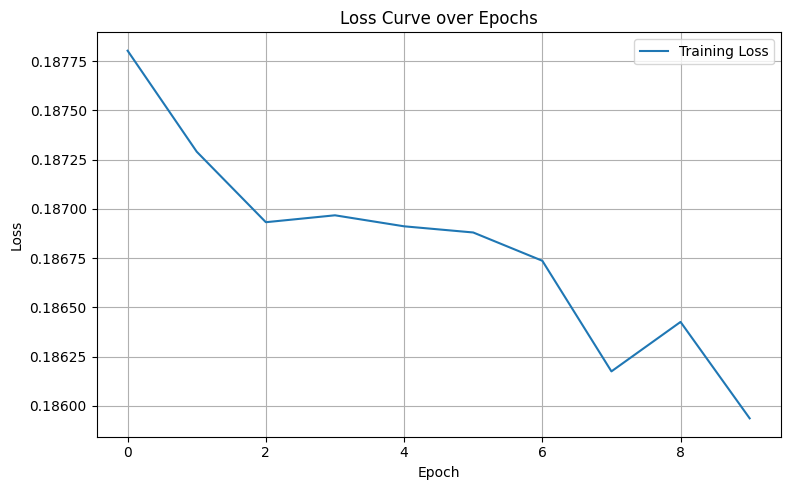

In [59]:
plt.figure(figsize=(15, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()